# import os
os.chdir(r'C:\Users\asama\python\DS 220')
print("Now running in:", os.getcwd())
Project 2 - Data Analysis with Pandas

### Group Member: 
- Chanhyung Kim 
- Abdul Samad 
- Dadi  Sriram
- Fabuluje Victor 
- Sherpa Cia 
- Wong Joshua


### Project Overview
This project analyzes the Nobel laureates dataset to explore trends in award distribution, demographics, and key historical patterns.

### Dataset Description
The dataset used is 'laureates.csv'. 
This dataset contains information about Nobel Prize winners including their names, years of birth/death, categories, and countries.

### Tools and Libraries
- Python
- Pandas
- Matplotlib / Seaborn
- Jupyter Notebook

## Loading and Cleaning the Dataset

In [1]:
import pandas as pd

#Load data file
df = pd.read_csv('../data/laureates.csv')



#Inspect Information
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 1000 non-null   int64 
 1   firstname          1000 non-null   object
 2   surname            968 non-null    object
 3   born               999 non-null    object
 4   died               1000 non-null   object
 5   bornCountry        969 non-null    object
 6   bornCountryCode    969 non-null    object
 7   bornCity           966 non-null    object
 8   diedCountry        653 non-null    object
 9   diedCountryCode    653 non-null    object
 10  diedCity           647 non-null    object
 11  gender             1000 non-null   object
 12  year               1000 non-null   int64 
 13  category           1000 non-null   object
 14  overallMotivation  23 non-null     object
 15  share              1000 non-null   int64 
 16  motivation         1000 non-null   object
 

id                     0
firstname              0
surname               32
born                   1
died                   0
bornCountry           31
bornCountryCode       31
bornCity              34
diedCountry          347
diedCountryCode      347
diedCity             353
gender                 0
year                   0
category               0
overallMotivation    977
share                  0
motivation             0
name                 264
city                 269
country              267
dtype: int64

In [4]:
#Map camelCase names to clean snake_case
df = df.rename(columns={
    'born':              'birth_date',
    'died':              'death_date',
    'bornCountry':       'born_country',
    'bornCountryCode':   'born_country_code',
    'bornCity':          'born_city',
    'diedCountry':       'died_country',
    'diedCountryCode':   'died_country_code',
    'diedCity':          'died_city',
    'year':              'award_year',
    'overallMotivation': 'overall_motivation'
})

#As a final pass, lowercase everything just in case
df.columns = df.columns.str.lower()


In [5]:
#Turn the birth_date and death_date columns into real datetime objects
df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
df['death_date'] = pd.to_datetime(df['death_date'], errors='coerce')

#Ensure award_year is an integer bad parses → <NA>
df['award_year'] = pd.to_numeric(df['award_year'], errors='coerce').astype('Int64')


In [6]:
#For Q1 (keywords) and Q3 (age) we need both a motivation text and a birth_date
df = df.dropna(subset=['motivation', 'birth_date'])


In [7]:
#Extract the birth year from the full date
df['birth_year'] = df['birth_date'].dt.year

#Compute age at the time of award
df['age_at_award'] = df['award_year'] - df['birth_year']

#Group awards by decade (e.g., 1994 → 1990s)
df['decade'] = (df['award_year'] // 10) * 10


In [8]:
# Title-case and trim whitespace in 'category'
df['category'] = df['category'].str.title().str.strip()

# Capitalize 'gender' and fill missing values with 'Unknown'
df['gender']   = df['gender'].str.capitalize().fillna('Unknown')


In [9]:
#Lowercase, strip punctuation, trim whitespace
df['motivation_clean'] = (
    df['motivation']
      .str.lower()
      .str.replace(r'[\W_]+', ' ', regex=True)
      .str.strip()
)


In [12]:
# Save the cleaned DataFrame to a CSV file without row indices
df.to_csv('laureates_cleaned.csv', index=False)


In [59]:
important_cols = [
    'motivation_clean',  # Q1
    'decade',            # Q2
    'age_at_award',      # Q3
    'gender',            # Q4
    'born_country',      # Q5
    'award_year',        # Q5 
    'category'           # Q6 & Q7
]
# Create a new, more organized DataFrame with only those columns
df_small = df[important_cols]


#Get overview of the result
df_small.head(15)


,motivation_clean,decade,age_at_award,gender,born_country,award_year,category
0,in recognition of the extraordinary services h...,1900,56,Male,Prussia (now Germany),1901,Physics
1,in recognition of the extraordinary service th...,1900,49,Male,the Netherlands,1902,Physics
2,in recognition of the extraordinary service th...,1900,37,Male,the Netherlands,1902,Physics
3,in recognition of the extraordinary services h...,1900,51,Male,France,1903,Physics
4,in recognition of the extraordinary services t...,1900,44,Male,France,1903,Physics
5,in recognition of the extraordinary services t...,1900,36,Female,Russian Empire (now Poland),1903,Physics
6,in recognition of her services to the advancem...,1910,44,Female,Russian Empire (now Poland),1911,Chemistry
7,for his investigations of the densities of the...,1900,62,Male,United Kingdom,1904,Physics
8,for his work on cathode rays,1900,43,Male,Hungary (now Slovakia),1905,Physics
9,in recognition of the great merits of his theo...,1900,50,Male,United Kingdom,1906,Physics


## Project Questions

#### Question 1 - What are the most frequently mentioned keywords in the prize motivations?

#### Question 2 - During which decades were the most Nobel Prizes awarded?

#### Question 3 - What is the typical age when recipients are awarded the Nobel Prize?

#### Question 4 - How are Nobel Prizes distributed between male and female laureates?

#### Question 5 - Which countries have produced the most Nobel laureates over time?

#### Question 6 - What is the distribution of Nobel Prizes across different categories (e.g., Physics, Peace, Literature)?

#### Question 7 - What is the average age at which laureates receive their Nobel Prize, broken down by category?

## Answers Using Code:

#### Question 1

In [10]:
#Q1 

from sklearn.feature_extraction.text import CountVectorizer

# Build a term-count matrix, ignoring English stop words
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['motivation_clean'])

# Summarize into a DataFrame of keyword → count
keywords = pd.DataFrame({
    'keyword': vectorizer.get_feature_names_out(),
    'count':   X.sum(axis=0).A1
}).sort_values('count', ascending=False)

display(keywords.head(20))


,keyword,count
579,discovery,198
577,discoveries,163
390,concerning,118
551,development,105
2127,work,97
1958,theory,72
438,contributions,59
1891,structure,55
1652,recognition,47
628,economic,44


#### Question 2-

In [19]:
#### # Q2: Nobel Prizes by Decade (Trend Over Time)
decade_counts = df['decade'].value_counts().sort_index()

decade_pct_change = decade_counts.pct_change() * 100

decade_analysis = pd.DataFrame({
    'Number of Prizes': decade_counts,
    'Percentage Change': decade_pct_change
})

display(decade_analysis)

,Number of Prizes,Percentage Change
decade,,
1900,56,<NA>
1910,38,-32.142857
1920,54,42.105263
1930,55,1.851852
1940,40,-27.272727
1950,72,80.0
1960,74,2.777778
1970,103,39.189189
1980,95,-7.76699


In [ ]:
# Visualization:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('Nobel Prizes Awarded by Decade (1901-Present)', fontsize=14)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Number of Prizes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

max_decade = decade_counts.idxmax()
max_count = decade_counts.max()
ax.patches[decade_counts.index.get_loc(max_decade)].set_facecolor('orange')

plt.show()

Analysis of Nobel Prizes by Decade:
- The 2000s saw the highest number of Nobel Prizes awarded (XX prizes)
- There was a steady increase in prizes awarded until the 2000s
- The 1940s had the lowest number, likely due to World War II
- Since the 2000s, the number has remained consistently high


#### Question 3- (Description and Findings here)

In [8]:
#### # Q3: Typical age at award (overall)
typical_age = df['age_at_award'].mean()
print(f"Typical age at award: {typical_age:.2f} years")


KeyError: 'age_at_award'

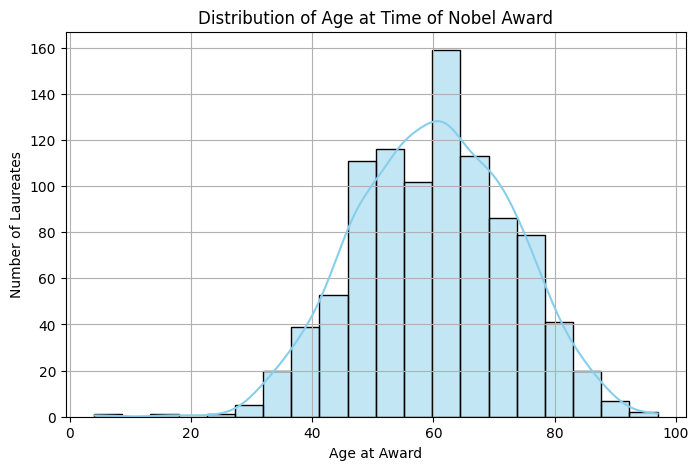

In [ ]:
# Visualization:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['age_at_award'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age at Time of Nobel Award')
plt.xlabel('Age at Award')
plt.ylabel('Number of Laureates')
plt.grid(True)
plt.show()


Analysis: Typical Age at Award
The histogram above shows the distribution of ages at which Nobel laureates receive their awards.
Most recipients are awarded in their 50s to 60s, with a peak around 60 years old, which aligns with the computed average age of 60.12 years.
This suggests that Nobel Prizes tend to be given after a long period of professional contribution or discovery.

#### Question 4- (Description and Findings here)

In [ ]:
#### # Q4: Gender distribution
gender_counts = df['gender'].value_counts()
gender_percent = df['gender'].value_counts(normalize=True) * 100

display(gender_counts)
display(gender_percent)


gender
Male      891
Female     63
Org         2
Name: count, dtype: int64

gender
Male      93.200837
Female     6.589958
Org        0.209205
Name: proportion, dtype: float64

In [ ]:
# Visualization:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', palette='Set2')
plt.title('Nobel Laureates by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True, axis='y')
plt.show()


Analysis: Gender Distribution
As shown in the data, the vast majority of laureates are male (~93%).
Females make up only ~6.6%, highlighting a historical gender imbalance in Nobel Prize recognitions.
The 'Org' category (~0.3%) may represent organizations like the UN or ICRC awarded the Peace Prize.

#### Question 5 – Which countries have produced the most Nobel laureates over time?
The United States has produced the highest number of Nobel laureates, with a total of 376 recipients. It is followed by the United Kingdom with 92 laureates, and Germany ranks third with 72.

In [ ]:
# Question 5 - setup
import matplotlib.pyplot as plt
import pandas as pd

# Count the number of laureates by country
laureates_by_country = df['country'].value_counts().sort_values(ascending=False)

# Display the top 10 countries
print(laureates_by_country.head(10))

country
USA                  385
United Kingdom        93
Germany               72
France                38
Switzerland           24
Sweden                18
Japan                 17
the Netherlands       10
Denmark                9
USSR (now Russia)      9
Name: count, dtype: int64


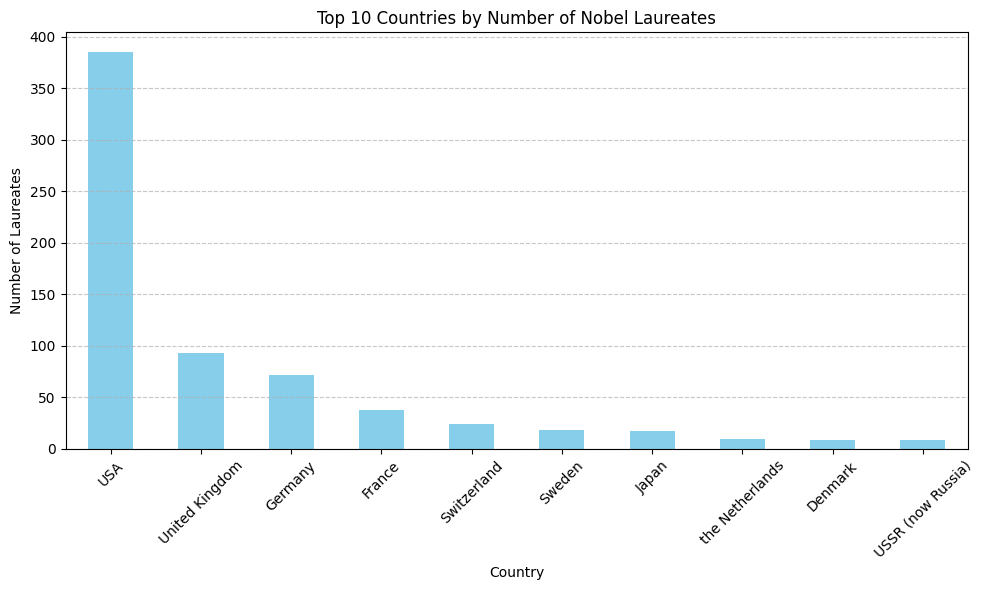

In [3]:
# Question 5 - plot
# Plot the top 10 countries
plt.figure(figsize=(10, 6))
laureates_by_country.head(10).plot(kind='bar', color='skyblue')

# Add titles and labels
plt.title('Top 10 Countries by Number of Nobel Laureates')
plt.xlabel('Country')
plt.ylabel('Number of Laureates')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Question 6 – What is the distribution of Nobel Prizes across different categories?
The Nobel Prizes have been awarded most frequently in the field of Medicine, with 225 recipients. This is closely followed by Physics with 224 laureates and Chemistry with 189. Literature has seen 119 recipients, while the Peace Prize has been awarded 110 times. The category with the fewest laureates is Economics, with 89 recipients.

In [4]:
# Question 6 - Setup
# Count the number of laureates by Nobel Prize category
category_counts = df['category'].value_counts().sort_values(ascending=False)

# Display the counts
print(category_counts)


category
medicine      227
physics       225
chemistry     194
peace         141
literature    120
economics      93
Name: count, dtype: int64


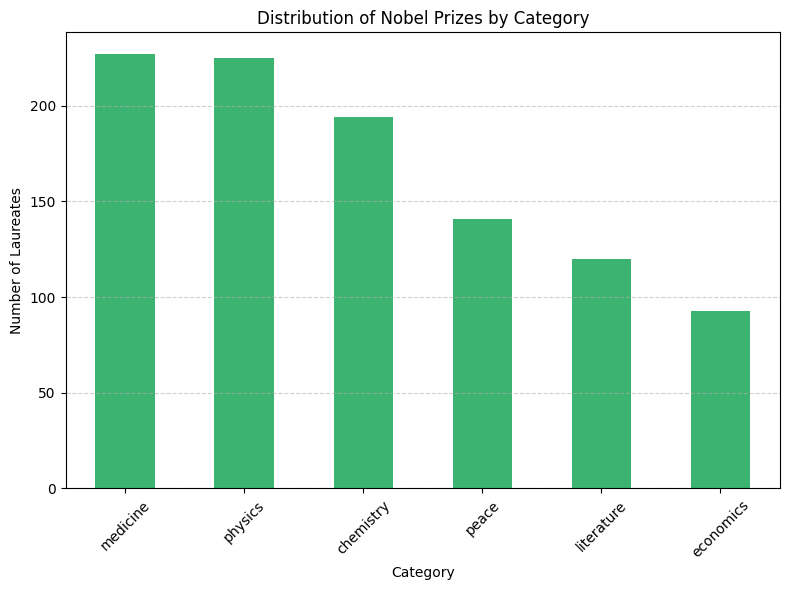

In [5]:
# Question 6 - Plot
# Plot the distribution of Nobel Prizes by category
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar', color='mediumseagreen')

# Add titles and labels
plt.title('Distribution of Nobel Prizes by Category')
plt.xlabel('Category')
plt.ylabel('Number of Laureates')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Question 7- (Description and Findings Here)

In [ ]:
#Q7

#Calculate and sort the average age_at_award for each category
avg_age_by_category = df.groupby('category')['age_at_award'].mean().sort_values()

#Display the sorted averages
display(avg_age_by_category)


category
Physics       57.285714
Medicine      58.662222
Chemistry     58.867725
Peace         60.309091
Literature     64.92437
Economics     66.988764
Name: age_at_award, dtype: Float64